<a href="https://colab.research.google.com/github/karna-charan/-Neural-Networks-and-Deep-Learning-/blob/main/future_air_temperat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

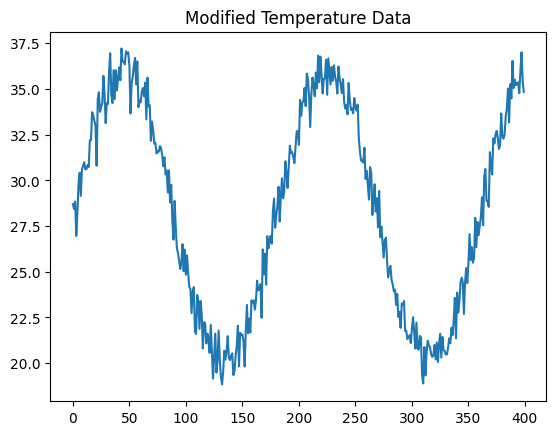

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.2087 - val_loss: 0.0247
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0258 - val_loss: 0.0126
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0139 - val_loss: 0.0140
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0113 - val_loss: 0.0065
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0088 - val_loss: 0.0054
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0070 - val_loss: 0.0074
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0064 - val_loss: 0.0048
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0059 - val_loss: 0.0064
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0057 - val_loss: 0.0065
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0056 - val_loss: 0.0060
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0053 - val_loss: 0.0063
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

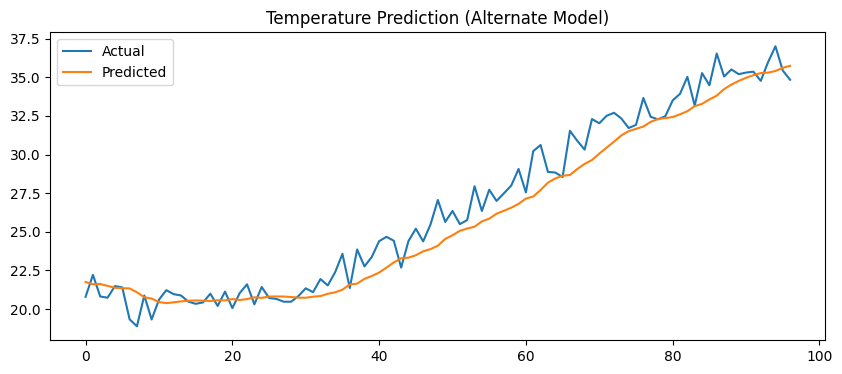

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Today's Temp: 34.84
Next Day Prediction: 35.71


In [2]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Step 2: Generate synthetic temperature data (changed values)
np.random.seed(20)
days = 400
t = np.arange(days)

# Different base temp, amplitude, and noise
temp = 28 + 8*np.sin(2*np.pi*t/180) + np.random.normal(0, 0.8, days)

plt.plot(temp)
plt.title("Modified Temperature Data")
plt.show()

# Step 3: Scaling
scaler = MinMaxScaler()
temp_scaled = scaler.fit_transform(temp.reshape(-1,1))

# Step 4: Sequence creation (different time step)
def create_seq(data, step=12):
    X, y = [], []
    for i in range(len(data)-step):
        X.append(data[i:i+step])
        y.append(data[i+step])
    return np.array(X), np.array(y)

time_step = 12
X, y = create_seq(temp_scaled, time_step)

# Step 5: Train-test split (75-25 split)
split = int(0.75 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Step 6: Build LSTM model (simpler architecture)
model = Sequential([
    LSTM(60, input_shape=(time_step, 1)),
    Dense(20, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Step 7: Train model (different epochs & batch size)
history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    verbose=1)

# Step 8: Predictions
pred_scaled = model.predict(X_test)

# Inverse transform
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test)

# Step 9: Evaluation
mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

# Step 10: Plot
plt.figure(figsize=(10,4))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Temperature Prediction (Alternate Model)")
plt.show()

# Step 11: Future prediction
last_seq = temp_scaled[-time_step:].reshape(1, time_step, 1)
future_scaled = model.predict(last_seq)
future = scaler.inverse_transform(future_scaled)

print("Today's Temp:", round(temp[-1],2))
print("Next Day Prediction:", round(future[0][0],2))